In [1]:
import joblib
import pandas as pd
from numpy.ma.core import log2, size
from streamlit import columns

from marginal_emissions.core.msdr import MSDRAnalyzer

In [2]:
tennet = pd.read_csv('../data/processed/test_final_tennet', index_col=0, decimal=',')

In [3]:
analyzer = MSDRAnalyzer(tso='tennet', data=tennet, run='test2_aic')

In [4]:
vars(analyzer)

{'root': PosixPath('/home/aklei/PycharmProjects/marginal-emissions-germany'),
 'tso': 'tennet',
 'run': 'test2_aic',
 'scaler': StandardScaler(),
 'df':                           total_generation total_emissions
 datetime                                                  
 2022-12-31 23:00:00+00:00           282.75           372.0
 2022-12-31 23:15:00+00:00           282.75           372.0
 2022-12-31 23:30:00+00:00           282.75           372.0
 2022-12-31 23:45:00+00:00           282.75           372.0
 2023-01-01 00:00:00+00:00           281.25          393.16
 ...                                    ...             ...
 2023-01-08 00:15:00+00:00            311.5          418.33
 2023-01-08 00:30:00+00:00            311.5          418.33
 2023-01-08 00:45:00+00:00            311.0          417.52
 2023-01-08 01:00:00+00:00           309.25          412.28
 2023-01-08 01:15:00+00:00            309.5          412.68
 
 [682 rows x 2 columns],
 'window_length': 672,
 'n_jobs': -1,
 'p

In [5]:
analyzer.prepare()

[INFO][2026-02-17 16:09:40][msdr.py] Starting data preparation...
[INFO][2026-02-17 16:09:40][msdr.py] I. DATA INSPECTION
[INFO][2026-02-17 16:09:40][msdr.py] Setting index to datetime...
[INFO][2026-02-17 16:09:40][msdr.py] Setting columns to numeric...

[INSPECTION]
  - Index Type: datetime64[ns, UTC]
  - Duplicate Entries: 0
  - Total Generation Type: float64
  - Negative Generation Values: 0
  - Total Emissions Type: float64
  - Negative Emissions Values: 0
  - Rows with NaN Values: 0

[INFO][2026-02-17 16:09:40][msdr.py] II. DATA PREPARATION
[INFO][2026-02-17 16:09:40][msdr.py] 1) Calculation delta for time series:
[INFO][2026-02-17 16:09:40][msdr.py] Setting index to datetime...
[INFO][2026-02-17 16:09:40][msdr.py] Setting columns to numeric...
                           total_generation  total_emissions
datetime                                                    
2022-12-31 23:15:00+00:00               0.0             0.00
2022-12-31 23:30:00+00:00               0.0             

,total_generation,total_emissions
datetime,,
2022-12-31 23:15:00+00:00,-0.003781,-0.005126
2022-12-31 23:30:00+00:00,-0.003781,-0.005126
2022-12-31 23:45:00+00:00,-0.003781,-0.005126
2023-01-01 00:00:00+00:00,-0.148174,1.810557
2023-01-01 00:15:00+00:00,-0.003781,-0.005126
...,...,...
2023-01-08 00:15:00+00:00,-0.003781,-0.005126
2023-01-08 00:30:00+00:00,-0.003781,-0.005126
2023-01-08 00:45:00+00:00,-0.051912,-0.074630


In [6]:
analyzer.fit()

[INFO][2026-02-17 16:09:42][msdr.py] Starting MSDR analysis for tennet on 10 rows...


Analyzing tennet...: 100%|██████████| 10/10 [00:00<00:00, 616.49it/s]


[INFO][2026-02-17 16:10:00][msdr.py] Analysis for tennet complete.



In [7]:
analyzer.compute()

[INFO][2026-02-17 16:10:00][msdr.py] Computing MEF from best models...
[INFO][2026-02-17 16:10:00][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_best_coefficients.csv
[INFO][2026-02-17 16:10:00][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_mef_scaled.csv
[INFO][2026-02-17 16:10:00][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/summary/summary.pkl
[INFO][2026-02-17 16:10:00][msdr.py] Inverse transforming coefficients to get absolute MEF
[INFO][2026-02-17 16:10:00][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_mef_absolute.csv


In [8]:
analyzer.merge_mef().dropna()

[INFO][2026-02-17 16:10:00][msdr.py] Merging MEF back to original data...
[INFO][2026-02-17 16:10:00][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_mef_final.csv


,total_generation,total_emissions,mef_t_MWh,mef_g_kWh,intercept
datetime,,,,,
2023-01-07 23:00:00+00:00,311.50,391.63,0.698749,698.749471,-0.291863
2023-01-07 23:15:00+00:00,311.50,391.63,0.900837,900.837229,0.008926
2023-01-07 23:30:00+00:00,311.50,391.63,0.888734,888.734376,0.012534
2023-01-07 23:45:00+00:00,311.50,391.63,0.900320,900.319553,0.008179
2023-01-08 00:00:00+00:00,311.50,418.33,0.699337,699.336668,-0.271780
2023-01-08 00:15:00+00:00,311.50,418.33,0.888983,888.983304,0.013066
2023-01-08 00:30:00+00:00,311.50,418.33,0.900328,900.327833,0.008393
2023-01-08 00:45:00+00:00,311.00,417.52,0.896295,896.294607,0.002191
2023-01-08 01:00:00+00:00,309.25,412.28,0.699135,699.134776,-0.308763


In [9]:
analyzer.predict()

[INFO][2026-02-17 16:10:01][msdr.py] Performing in-sample prediction with best models...
[INFO][2026-02-17 16:10:01][msdr.py] Plotting estimated emissions...
[INFO][2026-02-17 16:10:01][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/tables/df_estimated_emissions.csv
[INFO][2026-02-17 16:10:01][msdr.py] Estimated plot saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test2_aic/figures/tennet_run_test2_aic_msdr_prediction.png


In [37]:
import matplotlib.pyplot as plt
mef1 = pd.read_csv('../results/tennet_run_test1_mae/tables/df_mef_final.csv', index_col=0)
mef1.drop(columns=['total_generation', 'total_emissions', 'mef_t_MWh', 'intercept'], inplace=True)
mef2 = pd.read_csv('../results/tennet_run_test2_aic/tables/df_mef_final.csv', index_col=0)
mef2.drop(columns=['total_generation', 'total_emissions', 'mef_t_MWh', 'intercept'], inplace=True)
total_emissions_df = pd.read_csv('../results/tennet_run_test2_aic/tables/df_mef_final.csv', index_col=0)
total_emissions_df.drop(columns=['total_generation', 'mef_t_MWh', 'intercept', 'mef_g_kWh'], inplace=True)
print(f"mef1 = [{mef1.columns}], mef2 = [{mef2.columns}], total_emissions = [{total_emissions_df.columns}]")

mef1 = [Index(['mef_g_kWh'], dtype='object')], mef2 = [Index(['mef_g_kWh'], dtype='object')], total_emissions = [Index(['total_emissions'], dtype='object')]


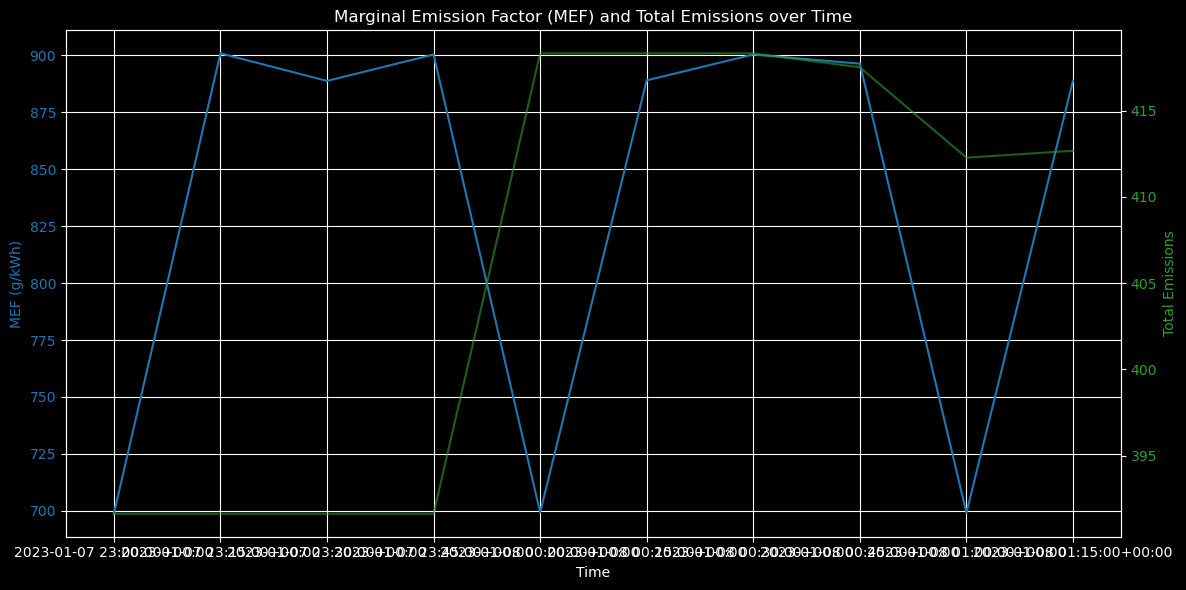

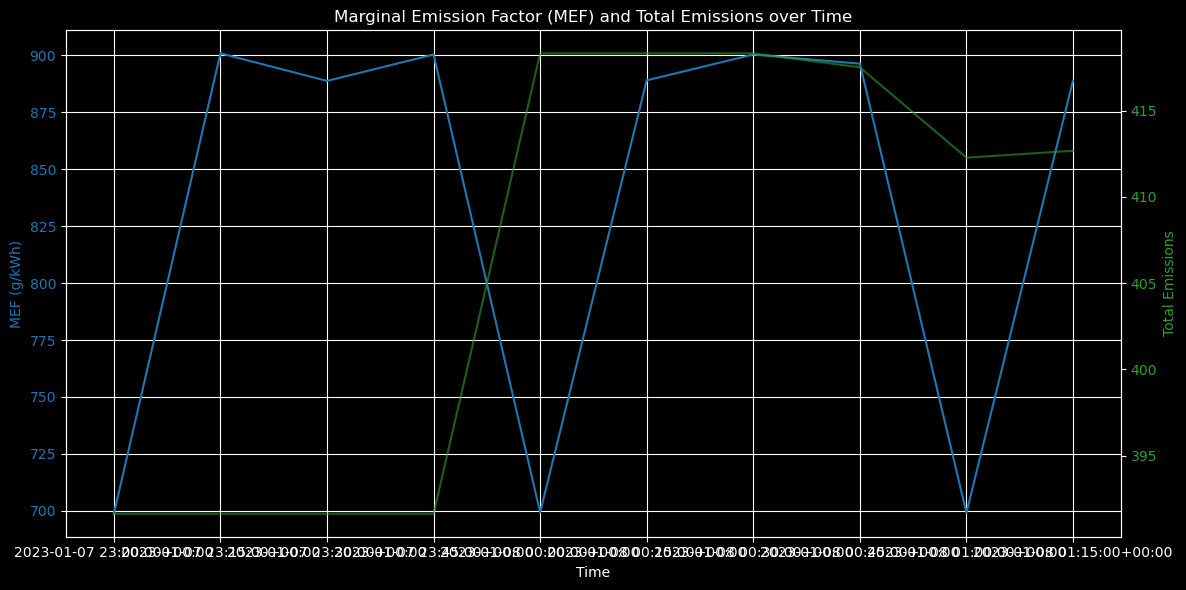

In [39]:
for mef in [mef1, mef2]:

    # Filter only rows where MEF has values (drop NaNs)
    mef_plot = mef.dropna()

    # Create a figure and a primary axis
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot MEF on the primary axis (left y-axis)
    color = 'tab:blue'
    ax1.set_xlabel('Time')
    ax1.set_ylabel('MEF (g/kWh)', color=color)
    ax1.plot(mef_plot.index, mef_plot, color=color, label='MEF (g/kWh)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    # Create a secondary axis sharing the same x-axis
    ax2 = ax1.twinx()

    # Plot Total Emissions on the secondary axis (right y-axis)
    # We need to align the index with mef to ensure same period
    current_emissions = total_emissions_df.loc[mef_plot.index, 'total_emissions']

    color = 'tab:green'
    ax2.set_ylabel('Total Emissions', color=color)
    ax2.plot(current_emissions.index, current_emissions, color=color, label='Total Emissions (tCO2)', alpha=0.6)
    ax2.tick_params(axis='y', labelcolor=color)

    # Title and layout
    plt.title('Marginal Emission Factor (MEF) and Total Emissions over Time')
    fig.tight_layout()  # Adjust the layout to prevent clipping
    plt.show()

In [12]:
vars(analyzer.best_model_results[0].mlefit)

{'params': array([ 6.04497660e-01,  7.52699145e-01, -8.32969412e-04, -2.78146051e-02,
         7.93620954e-01,  6.22862655e-01,  1.99138093e-02,  1.30746812e+00]),
 'model': <statsmodels.tsa.regime_switching.markov_regression.MarkovRegression at 0x755f3ca58cd0>,
 'k_constant': 1,
 '_data_attr': [],
 '_data_in_cache': ['fittedvalues', 'resid', 'wresid'],
 'normalized_cov_params': None,
 'scale': 1.0,
 '_use_t': False,
 'mle_retvals': {'fopt': np.float64(-0.4981880472047466),
  'gopt': array([ 4.53299432e-08, -3.45981685e-08, -3.80415846e-06, -1.52176453e-07,
          8.84500527e-07,  6.97218296e-07,  5.24839447e-06,  1.22580475e-08]),
  'Hinv': array([[ 6.95054402e+00, -1.69665113e-01, -6.43649407e-04,
          -6.78701040e-02,  1.80359502e-02, -1.17181382e-01,
           1.56078020e-02,  2.45251966e-01],
         [-1.69665113e-01,  1.43499203e+01,  4.08872574e-04,
           4.82735807e-01,  3.33685203e-02,  5.61718496e-01,
           2.81736571e-02,  5.52461429e-01],
         [-6.43

In [13]:
import joblib
summary = joblib.load('../results/tennet_run_test1_mae/summary/summary.pkl')

In [14]:
summary[0]

{'timestamp': Timestamp('2023-01-07 23:00:00+0000', tz='UTC'),
 'k_regimes': 2,
 'coeffs':                coef   std_err        tval           pval  ci_lower  ci_upper
 p[0->0]    0.646685  0.024423   26.478283  1.724308e-154  0.598816  0.694553
 p[1->0]    0.679767  0.034361   19.782994   4.171726e-87  0.612420  0.747113
 const[0]  -0.000833  0.001063   -0.783372   4.334085e-01 -0.002917  0.001251
 const[1]  -0.027815  0.086537   -0.321418   7.478937e-01 -0.197424  0.141795
 x1[0]      0.793621  0.003712  213.815978   0.000000e+00  0.786346  0.800896
 x1[1]      0.622863  0.053115   11.726591   9.313447e-32  0.518758  0.726967
 sigma2[0]  0.000397  0.000047    8.414899   3.932322e-17  0.000304  0.000489
 sigma2[1]  1.709473  0.164590   10.386247   2.864028e-25  1.386882  2.032063,
 'smoothed_probs': 0    0.0
 1    1.0
 Name: 2023-01-07 23:00:00+00:00, dtype: float64,
 'mae': np.float64(0.2928070193039523),
 'aic': np.float64(-653.5647354431794),
 'bic': np.float64(-617.4826687189942),

In [15]:
for i in range(len(summary)):
    params = analyzer.best_model_results[i]
    summary = analyzer.summary
    print(f"Converged: {summary[i]['mle_converged']}")
    print(f"No. Regimes: {summary[i]['k_regimes']}")
    print(f"AIC: {summary[i]['aic']}")
    print(f"MAE: {summary[i]['mae']}\n")
    #print("")

Converged: True
No. Regimes: 2
AIC: -653.5647354431794
MAE: 0.2928070193039523

Converged: True
No. Regimes: 2
AIC: -661.0073408053739
MAE: 0.2891554125998796

Converged: True
No. Regimes: 2
AIC: -653.6650329441316
MAE: 0.2928017574644449

Converged: True
No. Regimes: 2
AIC: -660.8369712700371
MAE: 0.2862850284039905

Converged: True
No. Regimes: 2
AIC: -652.6097994561308
MAE: 0.2932946431153779

Converged: True
No. Regimes: 2
AIC: -652.7102095818229
MAE: 0.2932898728324579

Converged: True
No. Regimes: 2
AIC: -660.0598443978892
MAE: 0.28966361301837423

Converged: True
No. Regimes: 2
AIC: -657.7434716068731
MAE: 0.2891348956686857

Converged: True
No. Regimes: 2
AIC: -650.0204379199522
MAE: 0.29329749524080156

Converged: True
No. Regimes: 2
AIC: -650.5395647494826
MAE: 0.29332275912829747



In [16]:
import joblib
summary2 = joblib.load('../results/tennet_run_test2_aic/summary/summary.pkl')

In [17]:
for i in range(len(summary2)):
    params = analyzer.best_model_results[i]
    summary2 = analyzer.summary
    print(f"Converged: {summary2[i]['mle_converged']}")
    print(f"No. Regimes: {summary2[i]['k_regimes']}")
    print(f"AIC: {summary2[i]['aic']}")
    print(f"MAE: {summary2[i]['mae']}\n")

Converged: True
No. Regimes: 2
AIC: -653.5647354431794
MAE: 0.2928070193039523

Converged: True
No. Regimes: 2
AIC: -661.0073408053739
MAE: 0.2891554125998796

Converged: True
No. Regimes: 2
AIC: -653.6650329441316
MAE: 0.2928017574644449

Converged: True
No. Regimes: 2
AIC: -660.8369712700371
MAE: 0.2862850284039905

Converged: True
No. Regimes: 2
AIC: -652.6097994561308
MAE: 0.2932946431153779

Converged: True
No. Regimes: 2
AIC: -652.7102095818229
MAE: 0.2932898728324579

Converged: True
No. Regimes: 2
AIC: -660.0598443978892
MAE: 0.28966361301837423

Converged: True
No. Regimes: 2
AIC: -657.7434716068731
MAE: 0.2891348956686857

Converged: True
No. Regimes: 2
AIC: -650.0204379199522
MAE: 0.29329749524080156

Converged: True
No. Regimes: 2
AIC: -650.5395647494826
MAE: 0.29332275912829747

